In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
import glob
import xarray as xr
PATH = "/Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/*"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]


File 0: /Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/station_1.nc
<xarray.Dataset> Size: 58MB
Dimensions:              (valid_time: 750192)
Coordinates:
    station              int64 8B ...
  * valid_time           (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-...
    latitude             float64 8B ...
    longitude            float64 8B ...
    station_latitude     float64 8B ...
    station_longitude    float64 8B ...
    year                 (valid_time) int64 6MB ...
Data variables: (12/15)
    u10                  (valid_time) float32 3MB ...
    v10                  (valid_time) float32 3MB ...
    d2m                  (valid_time) float32 3MB ...
    t2m                  (valid_time) float32 3MB ...
    msl                  (valid_time) float32 3MB ...
    sst                  (valid_time) float32 3MB ...
    ...                   ...
    mwp                  (valid_time) float32 3MB ...
    swh                  (valid_time) float32 3MB ...
    sea_level     

In [3]:
ds = xr.concat(datasets, dim='station')

In [4]:
ds

<xarray.Dataset> Size: 14GB
Dimensions:              (station: 295, valid_time: 750192)
Coordinates:
  * station              (station) int64 2kB 1 10 102 103 104 ... 94 95 96 97 99
  * valid_time           (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-...
    latitude             float64 8B 48.38
    longitude            float64 8B -4.495
    station_latitude     (station) float64 2kB 48.38 45.57 50.1 ... 49.18 49.48
    station_longitude    (station) float64 2kB -4.495 -1.062 ... -2.117 0.1146
    year                 (valid_time) int64 6MB 1940 1940 1940 ... 2025 2025
Data variables: (12/15)
    u10                  (station, valid_time) float32 885MB -4.661 ... 5.358
    v10                  (station, valid_time) float32 885MB 7.723 ... 1.459
    d2m                  (station, valid_time) float32 885MB 277.2 ... 289.0
    t2m                  (station, valid_time) float32 885MB 280.1 ... 290.9
    msl                  (station, valid_time) float32 885MB 1.014e+05 ... 1....
    sst                  (station, valid_time) float32 885MB 283.5 ... 292.2
    ...                   ...
    mwp                  (station, valid_time) float32 885MB nan nan ... 3.357
    swh                  (station, valid_time) float32 885MB nan nan ... 0.4357
    sea_level            (station, valid_time) float32 885MB nan nan ... nan nan
    tide                 (station, valid_time) float64 2GB -1.239 ... 0.7854
    residual             (station, valid_time) float32 885MB nan nan ... nan nan
    residual_is_deviant  (station, valid_time) int8 221MB 0 0 0 0 0 ... 0 0 0 0
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

# Select times and days where GEV is fitted

In [9]:
import warnings
warnings.filterwarnings("ignore")

In [43]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats as st
import pandas as pd
from sklearn.cluster import KMeans  # (still unused)

# --- config ---
TARGET_VAR = "residual"
N_STATIONS = 295
CSV_OUT = "gev_fit_scoresEW.csv"
BIMONTHLY_OUT = "bimonthly_values_at_gev_timesEW.csv"
RESAMPLE_RULE = "2M"  # 2-month blocks (month-end anchored)

if TARGET_VAR not in ds.data_vars:
    # fall back to "first numeric data var" if residual isn't present
    for v in ds.data_vars:
        if np.issubdtype(ds[v].dtype, np.number):
            TARGET_VAR = v
            print(f"Using variable '{TARGET_VAR}' (first numeric data variable).")
            break
    else:
        raise ValueError("No numeric data variable found to fit.")

# Helper to safely get station coordinates for labeling
def _meta_for_station(i):
    lat = None
    lon = None
    try:
        lat = float(ds["station_latitude"].sel(station=i))
        lon = float(ds["station_longitude"].sel(station=i))
    except Exception:
        try:
            lat = float(ds["latitude"])
            lon = float(ds["longitude"])
        except Exception:
            pass
    return lat, lon

# Helper to get the time dimension for a single-station DataArray
def _time_dim(da):
    candidates = [d for d in da.dims if d not in ("station", "stations")]
    if not candidates:
        raise ValueError("Could not infer time dimension.")
    return candidates[0]

# Goodness-of-fit helpers
def kuiper_statistic(x, cdf_func):
    x = np.sort(np.asarray(x))
    n = x.size
    i = np.arange(1, n + 1)
    F_emp = i / n
    F_mod = cdf_func(x)
    D_plus = np.max(F_emp - F_mod)
    D_minus = np.max(F_mod - (i - 1) / n)
    return D_plus + D_minus

def r2_cdf_fit(x, cdf_func):
    x = np.sort(np.asarray(x))
    n = x.size
    i = np.arange(1, n + 1)
    F_emp = i / (n + 1.0)
    F_mod = cdf_func(x)
    ss_res = np.sum((F_emp - F_mod) ** 2)
    ss_tot = np.sum((F_emp - np.mean(F_emp)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1 - ss_res / ss_tot

stations = np.array(ds["station"].values)[:N_STATIONS]

fit_results = []
bimonthly_rows = []

# Eligible variables for extraction:
# keep only data_vars that are scalar per (station,time), i.e. dims subset of {station, tdim}
# (we will decide tdim per station from TARGET_VAR)
all_vars = list(ds.data_vars)

for s in stations:
    # DataArray for this station
    da = ds[TARGET_VAR].sel(station=s)

    # infer time dimension
    try:
        tdim = _time_dim(da)
    except Exception as e:
        print(f"Skipping station {s}: cannot infer time dim ({e}).")
        continue

    # drop NaNs/infs
    da = da.where(np.isfinite(da), drop=True)

    if da.size < 10:
        print(f"Skipping station {s}: not enough data after cleaning.")
        continue

    # 2-month block maxima and the time-of-maximum within each block
    try:
        r = da.resample({tdim: RESAMPLE_RULE})

        da_max = r.max()  # block maxima values (time coord is block label)
        # extraction time (timestamp at which the max occurred in the original series)
        da_tmax = r.map(lambda x: x.idxmax(dim=tdim))  # same block labels
    except Exception as e:
        print(f"Skipping station {s}: resample/idxmax failed ({e}).")
        continue

    # Flatten and clean maxima + extraction times consistently
    # (keep only blocks where both max and time-of-max are finite/non-null)
    valid = np.isfinite(da_max.values) & pd.notnull(da_tmax.values)
    if valid.sum() < 5:
        print(f"Skipping station {s}: not enough bimonthly maxima ({valid.sum()}).")
        continue

    x = da_max.values[valid].ravel()
    t_block = da_max[tdim].values[valid]      # block label timestamps (e.g., month-end)
    t_extract = da_tmax.values[valid].ravel() # actual timestamps of maxima

    # Fit GEV to block maxima
    gev_params = st.genextreme.fit(x)
    c, loc, scale = gev_params

    def gev_cdf(z):
        return st.genextreme.cdf(z, c, loc=loc, scale=scale)

    ks_stat, ks_p = st.kstest(x, "genextreme", args=gev_params)
    kuiper = kuiper_statistic(x, gev_cdf)
    r2 = r2_cdf_fit(x, gev_cdf)

    lat, lon = _meta_for_station(s)

    fit_results.append(
        {
            "station": int(s),
            "lat": lat,
            "lon": lon,
            "n_blocks": int(x.size),
            "gev_c": c,
            "gev_loc": loc,
            "gev_scale": scale,
            "ks_stat": ks_stat,
            "ks_pvalue": ks_p,
            "kuiper": kuiper,
            "r2_cdf": r2,
        }
    )

    # --- Subsample ds at extraction times to get bimonthly "event-aligned" values for every variable ---
    # Build an indexer with a NEW dimension "block" to avoid collisions with the original time dim name.
    extract_times = xr.DataArray(
        t_extract,
        dims=("block",),
        coords={"block": t_block},  # coordinate block labels for readability
        name="extract_time",
    )

    # Start each bimonthly row with station + block info + target max + extract_time
    base = pd.DataFrame(
        {
            "station": int(s),
            "block_time": pd.to_datetime(t_block),
            "extract_time": pd.to_datetime(t_extract),
            "target_block_max": x,
        }
    )

    # For each variable, extract values at the TARGET_VAR max-times (same station)
    # Only include variables that are scalar per (station,time): dims subset of {station, tdim}
    for v in all_vars:
        dv = ds[v]
        dims = set(dv.dims)

        if "station" not in dims or tdim not in dims:
            continue
        if not dims.issubset({"station", tdim}):
            # skip variables with extra dims (e.g., level, member, etc.)
            continue

        try:
            dv_s = dv.sel(station=s)
            # select at the extraction times; result will be indexed by "block"
            extracted = dv_s.sel({tdim: extract_times})
            # convert to 1D array aligned with base rows
            base[v] = np.asarray(extracted.values).ravel()
        except Exception:
            # if selection fails (e.g. non-unique times), skip safely
            continue

    bimonthly_rows.append(base)

# Save outputs
df_fit = pd.DataFrame(fit_results)
if df_fit.empty:
    raise RuntimeError("No stations were successfully fitted. Check your data and config.")
df_fit.to_csv(CSV_OUT, index=False)
print(f"Saved GEV fit parameters and scores to: {CSV_OUT}")

if bimonthly_rows:
    df_bi = pd.concat(bimonthly_rows, ignore_index=True)
    df_bi.to_csv(BIMONTHLY_OUT, index=False)
    print(f"Saved bimonthly values at GEV extraction times to: {BIMONTHLY_OUT}")
else:
    raise RuntimeError("No bimonthly extracted values were produced.")


Skipping station 110: not enough data after cleaning.
Skipping station 112: not enough data after cleaning.
Skipping station 113: not enough data after cleaning.
Skipping station 143: not enough data after cleaning.
Skipping station 145: not enough data after cleaning.
Skipping station 159: not enough data after cleaning.
Skipping station 276: not enough data after cleaning.
Skipping station 466: not enough data after cleaning.
Skipping station 472: not enough data after cleaning.
Skipping station 480: not enough data after cleaning.
Skipping station 518: not enough data after cleaning.
Skipping station 525: not enough data after cleaning.
Skipping station 557: not enough data after cleaning.
Skipping station 558: not enough data after cleaning.
Skipping station 564: not enough data after cleaning.
Skipping station 96: not enough data after cleaning.
Saved GEV fit parameters and scores to: gev_fit_scoresEW.csv
Saved bimonthly values at GEV extraction times to: bimonthly_values_at_gev_t

# Feature engineering

In [44]:
df_bi["magnitude"] = np.sqrt((df_bi["u10"]**2 )* (df_bi["v10"]**2))
df_bi["wind_dir"] = np.degrees(np.arctan2(df_bi["u10"], df_bi["v10"])) % 360
df_bi["u10_abs"] = df_bi["u10"].abs()
df_bi["v10_abs"] = df_bi["v10"].abs()
df_bi["wind_wave_diff"] =  df_bi["mwd"] - df_bi["wind_dir"]
df_bi["wind_wave_alignment"] =  np.cos(df_bi["wind_dir"] - df_bi["mwd"])
rho_air = 1.225      # kg m-3
Cd = 1.3e-3          # neutral drag coefficient
df_bi["tau_u"] = rho_air * Cd * df_bi["magnitude"] * df_bi["u10"]
df_bi["tau_v"] = rho_air * Cd * df_bi["magnitude"]  * df_bi["v10"]
df_bi["tau_mag"] = rho_air * Cd * df_bi["magnitude"] **2

In [45]:
del df_bi['target_block_max']
del df_bi['sea_level']

In [46]:
import pandas as pd
import numpy as np

# ensure datetime
df_bi["extract_time"] = pd.to_datetime(df_bi["extract_time"])
df_bi["year"] = df_bi["extract_time"].dt.year

# numeric columns only
num_cols = df_bi.select_dtypes(include=[np.number]).columns
num_cols = [c for c in num_cols if c not in ["station", "year"]]

# ---------- basic stats ----------
basic_stats = (
    df_bi
    .groupby("station")[num_cols]
    .agg([
        "mean",
        "std",
        lambda x: x.quantile(0.95),
        lambda x: x.quantile(0.99),
    ])
)

# rename lambda columns
basic_stats.columns = [
    f"{var}_{stat if isinstance(stat,str) else 'q95' if i%2==0 else 'q99'}"
    for i,(var,stat) in enumerate(basic_stats.columns)
]

# ---------- annual maxima ----------
annual_max = (
    df_bi
    .groupby(["station", "year"])[num_cols]
    .max()
)

ann_stats = annual_max.groupby("station").agg(["mean", "max"])
ann_stats.columns = [f"{var}_annmaxmean" if stat=="mean" else f"{var}_annmaxmax"
                     for var,stat in ann_stats.columns]

# ---------- combine ----------
stats_df = pd.concat([basic_stats, ann_stats], axis=1).reset_index()

In [58]:
# extract station coords as a DataFrame
coords_df = (
    ds[["station_latitude", "station_longitude"]]
    .to_dataframe()
    .reset_index()[["station", "station_latitude", "station_longitude"]]
    .drop_duplicates("station")
)

coords_df = coords_df.rename(columns={
    "station_latitude": "lat",
    "station_longitude": "lon"
})

# merge into stats_df
stats_df = stats_df.merge(coords_df, on="station", how="left")

# coastal alignment

In [ ]:
import numpy as np
import pandas as pd
import cartopy.io.shapereader as shpreader
from shapely.geometry import Point, LineString, MultiLineString
from shapely.ops import unary_union, nearest_points

# --------------------------
# helpers: bearings & angles
# --------------------------
def bearing_deg(lon1, lat1, lon2, lat2):
    """
    Initial bearing from (lon1,lat1) to (lon2,lat2) in degrees [0,360).
    Uses a spherical approximation (fine at ~0.1° scales).
    """
    lon1, lat1, lon2, lat2 = map(np.deg2rad, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    brng = np.rad2deg(np.arctan2(x, y))
    return (brng + 360) % 360

def ang_diff_deg(a, b):
    """Smallest signed angle difference a-b in degrees, in (-180, 180]."""
    d = (a - b + 180) % 360 - 180
    return d

def coast_tangent_bearing(coast_geom, lon, lat, radius_deg=0.1):
    """
    Estimate local coastline tangent bearing near (lon,lat).
    - coast_geom: shapely (Multi)LineString in lon/lat.
    - radius_deg: search radius in degrees.
    Returns: tangent bearing (deg) or np.nan if not found.
    """
    p = Point(lon, lat)
    # Quick local window to avoid heavy ops
    buf = p.buffer(radius_deg)

    local = coast_geom.intersection(buf)
    if local.is_empty:
        return np.nan

    # Ensure we have a linestring to work with
    if isinstance(local, (MultiLineString,)):
        # Merge components; if still multi, keep as is
        local = unary_union(local)

    # Find nearest point on local coastline to station
    try:
        p_near = nearest_points(p, local)[1]
    except Exception:
        return np.nan

    # Project nearest point onto the local geometry and sample slightly along it
    # Use a small step in "degrees" along the line coordinate system.
    # If local is multilines, choose the closest component
    if isinstance(local, MultiLineString):
        parts = list(local.geoms)
        dists = [p.distance(g) for g in parts]
        line = parts[int(np.argmin(dists))]
    else:
        line = local

    if not isinstance(line, LineString) or line.length == 0:
        return np.nan

    # distance along line of nearest point
    d0 = line.project(p_near)

    # step along line for tangent estimate
    step = max(line.length * 0.02, 0.002)  # adaptive but bounded (~0.002° min)
    d1 = np.clip(d0 - step, 0, line.length)
    d2 = np.clip(d0 + step, 0, line.length)

    p1 = line.interpolate(d1)
    p2 = line.interpolate(d2)

    # tangent bearing along coastline direction
    return bearing_deg(p1.x, p1.y, p2.x, p2.y)

# --------------------------
# load coastline geometry
# --------------------------
# Choose Natural Earth resolution: 10m is detailed but heavier; 50m is faster.
coast_shp = shpreader.natural_earth(resolution="10m", category="physical", name="coastline")
reader = shpreader.Reader(coast_shp)
coast_geoms = list(reader.geometries())
coast_geom = unary_union(coast_geoms)  # one combined geometry

# --------------------------
# compute for each station
# --------------------------
radius_deg = 0.1  # your requested neighborhood scale

out = []
for _, r in stats_df[["station", "lon", "lat"]].dropna().iterrows():
    b = coast_tangent_bearing(coast_geom, r["lon"], r["lat"], radius_deg=radius_deg)
    out.append((r["station"], b))

coast_df = pd.DataFrame(out, columns=["station", "coast_bearing_deg"])

# attach to stats_df
stats_df = stats_df.merge(coast_df, on="station", how="left")

# derive coastline normals (perpendiculars)
stats_df["coast_normal1_deg"] = (stats_df["coast_bearing_deg"] + 90) % 360
stats_df["coast_normal2_deg"] = (stats_df["coast_bearing_deg"] - 90) % 360

In [68]:
stats_df["wind_to_mean_deg"] = (stats_df["wind_dir_mean"] + 180) % 360
w = stats_df["wind_to_mean_deg"]

d1 = ang_diff_deg(w, stats_df["coast_normal1_deg"])
d2 = ang_diff_deg(w, stats_df["coast_normal2_deg"])

stats_df["wind_vs_coast_normal_diff_deg"] = np.where(np.abs(d1) < np.abs(d2), d1, d2)
stats_df["wind_more_alongshore_deg"] = ang_diff_deg(w, stats_df["coast_bearing_deg"])  # 0 means alongshore

In [69]:
stats_df.columns

Index(['station', 'u10_mean', 'u10_std', 'u10_<lambda_0>', 'u10_<lambda_1>',
       'v10_mean', 'v10_std', 'v10_<lambda_0>', 'v10_<lambda_1>', 'd2m_mean',
       ...
       'tau_mag_annmaxmean', 'tau_mag_annmaxmax', 'lat', 'lon',
       'coast_bearing_deg', 'coast_normal1_deg', 'coast_normal2_deg',
       'wind_to_mean_deg', 'wind_vs_coast_normal_diff_deg',
       'wind_more_alongshore_deg'],
      dtype='object', length=147)

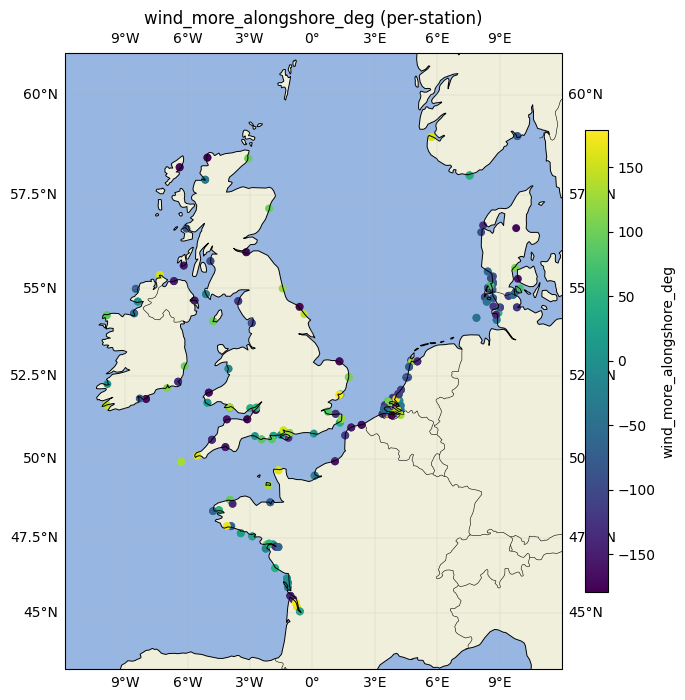

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# column you want
col = "wind_more_alongshore_deg"

# basic cleaning
plot_df = stats_df[["lon", "lat", col]].copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["lon", "lat", col])

# --- map ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.Mercator())

# Set an extent if you want (optional). Comment out to auto-scale.
pad = 2
ax.set_extent(
    [plot_df["lon"].min()-pad, plot_df["lon"].max()+pad,
     plot_df["lat"].min()-pad, plot_df["lat"].max()+pad],
    crs=proj
)

ax.add_feature(cfeature.LAND, zorder=0)
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

sc = ax.scatter(
    plot_df["lon"], plot_df["lat"],
    c=plot_df[col],
    s=22,
    transform=proj
)

cb = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.03)
cb.set_label(col)

ax.set_title(f"{col} (per-station)")
plt.show()

near 0 wind is close to cross-shore/onshore

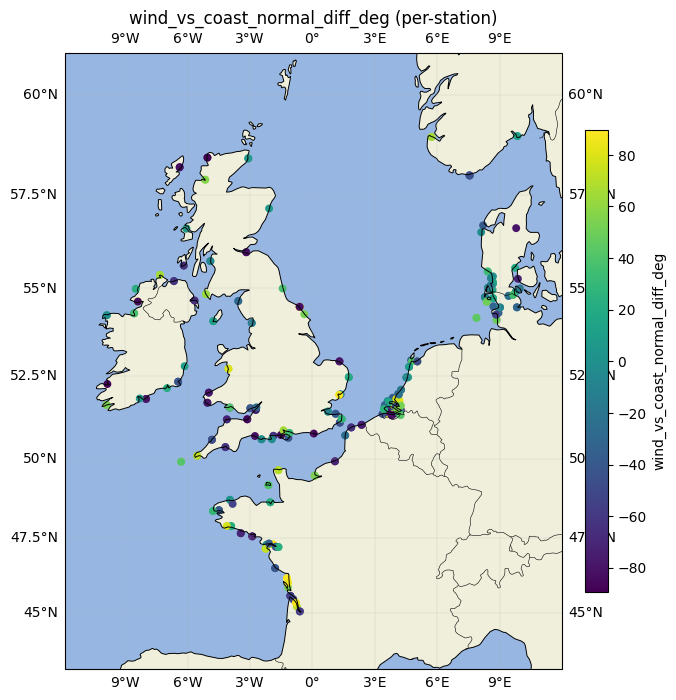

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# column you want
col = "wind_vs_coast_normal_diff_deg"

# basic cleaning
plot_df = stats_df[["lon", "lat", col]].copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["lon", "lat", col])

# --- map ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.Mercator())

# Set an extent if you want (optional). Comment out to auto-scale.
pad = 2
ax.set_extent(
    [plot_df["lon"].min()-pad, plot_df["lon"].max()+pad,
     plot_df["lat"].min()-pad, plot_df["lat"].max()+pad],
    crs=proj
)

ax.add_feature(cfeature.LAND, zorder=0)
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

sc = ax.scatter(
    plot_df["lon"], plot_df["lat"],
    c=plot_df[col],
    s=22,
    transform=proj
)

cb = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.03)
cb.set_label(col)

ax.set_title(f"{col} (per-station)")
plt.show()


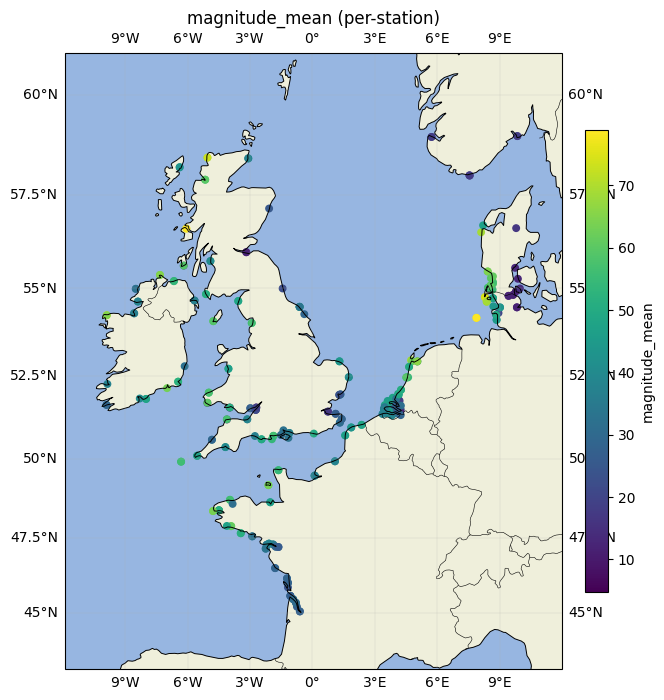

In [65]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# column you want
col = "magnitude_mean"

# basic cleaning
plot_df = stats_df[["lon", "lat", col]].copy()
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["lon", "lat", col])

# --- map ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=ccrs.Mercator())

# Set an extent if you want (optional). Comment out to auto-scale.
pad = 2
ax.set_extent(
    [plot_df["lon"].min()-pad, plot_df["lon"].max()+pad,
     plot_df["lat"].min()-pad, plot_df["lat"].max()+pad],
    crs=proj
)

ax.add_feature(cfeature.LAND, zorder=0)
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)

sc = ax.scatter(
    plot_df["lon"], plot_df["lat"],
    c=plot_df[col],
    s=22,
    transform=proj
)

cb = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.03)
cb.set_label(col)

ax.set_title(f"{col} (per-station)")
plt.show()

In [48]:
stats_df.to_csv("GEV_station_variable_statistics.csv", index=False)